# Chesapeake — Tutorial: OlmoEarth Embedding Extraction (real Sentinel-2)

End-to-end executable walkthrough: pick 4 Chesapeake watershed gauges, pull real Sentinel-2 L2A imagery for each from Microsoft Planetary Computer, normalize with the published OlmoEarth pretraining band statistics, run a forward pass through **OlmoEarth-V1-Nano**, and compare the resulting per-station 128-d embeddings.

## What You'll Learn

- How to pick stations and fetch real Sentinel-2 L2A imagery from Planetary Computer
- How to apply OlmoEarth's per-band normalization (without it, embeddings are meaningless)
- How to construct `MaskedOlmoEarthSample` from real data and run a forward pass
- How to read and compare per-station OlmoEarth embeddings

## Why

Owning real OlmoEarth embedding extraction means you can swap any tabular or hand-crafted feature for satellite-derived semantic features. This is the *primary upgrade path* for any geospatial downstream task — nutrient classification, plume tracking, land use, etc.

## Requirements

- Python 3.11
- `torch` (CUDA strongly recommended), `olmoearth_pretrain`
- `planetary_computer`, `pystac_client`, `rasterio`
- Network access (downloads ~few MB per station from Planetary Computer)
- Runtime: ~2 minutes on GPU

In [1]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import rasterio
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds
import planetary_computer
import pystac_client

from datasets import load_dataset
from olmoearth_pretrain.model_loader import ModelID, load_model_from_id
from olmoearth_pretrain.datatypes import MaskedOlmoEarthSample, MaskValue
from olmoearth_pretrain.data.normalize import load_computed_config
from olmoearth_pretrain.data.constants import Modality

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

# --- Constants ---
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PATCH_SIZE = 16
TIMESTEPS = 12
IMAGE_SIZE = 64
NUM_S2_BANDS = Modality.SENTINEL2_L2A.num_bands
S2_BAND_ORDER = ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07',
                 'B08', 'B09', 'B11', 'B12', 'B8A']

print(f"Device:        {DEVICE}")
print(f"Tile size:     {IMAGE_SIZE}x{IMAGE_SIZE} px (~{IMAGE_SIZE * 10}m at S2 10m GSD)")
print(f"S2 band order: {S2_BAND_ORDER}")

Device:        cuda
Tile size:     64x64 px (~640m at S2 10m GSD)
S2 band order: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B11', 'B12', 'B8A']


## 1. Pick 4 stations from the Chesapeake dataset

Diverse selection: the highest-TN station per sub-basin. Spreads samples across the watershed so the embeddings should be visibly different from one another.

In [2]:
ds = load_dataset("BAIGroup/OlmoEarth-v1-Chesapeake-Bay-Nutrient-Loads")
df = ds["train"].to_pandas()

station_summary = (
    df.groupby('STAID')
      .agg(station_name=('station_name', 'first'),
           subbasin=('subbasin', 'first'),
           latitude=('latitude', 'first'),
           longitude=('longitude', 'first'),
           mean_tn=('tn_load', 'mean'))
      .reset_index()
)

# Top-TN station from each sub-basin
selected = (
    station_summary.sort_values('mean_tn', ascending=False)
                    .groupby('subbasin', as_index=False)
                    .first()
                    .sort_values('mean_tn', ascending=False)
                    .head(4)
                    .reset_index(drop=True)
)
print("Selected 4 stations (top TN loader per sub-basin):")
selected[['STAID', 'station_name', 'subbasin', 'latitude', 'longitude']].round(4)

Selected 4 stations (top TN loader per sub-basin):


,STAID,station_name,subbasin,latitude,longitude
0,01578310,"SUSQUEHANNA RIVER AT CONOWINGO, MD",susquehanna,39.6579,-76.1744
1,01646580,"POTOMAC RIVER AT CHAIN BRIDGE, AT WASHINGTON, DC",potomac,38.9296,-77.1169
2,02035000,"JAMES RIVER AT CARTERSVILLE, VA",james,37.6710,-78.0858
3,01487000,"NANTICOKE RIVER NEAR BRIDGEVILLE, DE",patuxent_choptank,38.7283,-75.5619


## 2. Fetch real Sentinel-2 L2A imagery from Planetary Computer

For each station: build a small bbox around its lat/lon, search Planetary Computer's Sentinel-2 L2A catalog for the least-cloudy June 2020 scene, and read the 12 spectral bands at 64×64 px. Sentinel-2 tiles are stored in UTM, so the WGS84 bbox is reprojected to each raster's CRS before windowing.

In [3]:
def make_bbox(lat, lon, half_m=320):
    """Build a WGS84 bbox of half-side `half_m` meters around (lat, lon)."""
    deg_per_m_lat = 1 / 110_540
    deg_per_m_lon = 1 / (111_320 * np.cos(np.radians(lat)))
    return (lon - half_m * deg_per_m_lon, lat - half_m * deg_per_m_lat,
            lon + half_m * deg_per_m_lon, lat + half_m * deg_per_m_lat)

def fetch_sentinel2(catalog, lat, lon, year_month_start, year_month_end,
                     image_size=IMAGE_SIZE, max_cloud=30, retries=3):
    """Fetch the least-cloudy Sentinel-2 L2A composite for one station.

    Returns (H, W, num_bands) array of raw band values, or None if no scene is available."""
    bbox_wgs = make_bbox(lat, lon)
    items = None
    for attempt in range(retries):
        try:
            search = catalog.search(
                collections=["sentinel-2-l2a"],
                bbox=bbox_wgs,
                datetime=f"{year_month_start}/{year_month_end}",
                query={"eo:cloud_cover": {"lt": max_cloud}},
            )
            items = list(search.items())
            break
        except Exception as e:
            if attempt == retries - 1:
                print(f"    PC search failed after {retries} attempts: {type(e).__name__}")
                return None
            time.sleep(2 ** attempt)
    if not items:
        return None
    item = sorted(items, key=lambda i: i.properties['eo:cloud_cover'])[0]
    bands = []
    for b in S2_BAND_ORDER:
        href = item.assets[b].href
        with rasterio.open(href) as src:
            bbox_utm = transform_bounds("EPSG:4326", src.crs, *bbox_wgs)
            window = from_bounds(*bbox_utm, transform=src.transform)
            arr = src.read(1, window=window, out_shape=(image_size, image_size))
            bands.append(arr.astype(np.float32))
    return np.stack(bands, axis=-1), item.id, item.properties['eo:cloud_cover']

catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

print("Fetching Sentinel-2 L2A for each station (June 2020, least-cloudy)...")
raw_imagery = []
for _, row in selected.iterrows():
    print(f"  {row['STAID']} ({row['station_name'][:40]})...", end=" ", flush=True)
    result = fetch_sentinel2(catalog, row['latitude'], row['longitude'],
                              "2020-06-01", "2020-06-30")
    if result is None:
        print("NO IMAGERY AVAILABLE")
        raw_imagery.append(None)
    else:
        arr, item_id, cloud_pct = result
        print(f"{item_id} (cloud {cloud_pct:.1f}%)")
        raw_imagery.append(arr)

n_valid = sum(1 for x in raw_imagery if x is not None)
print(f"\nFetched imagery for {n_valid} of {len(selected)} stations")

Fetching Sentinel-2 L2A for each station (June 2020, least-cloudy)...
  01578310 (SUSQUEHANNA RIVER AT CONOWINGO, MD)... 

S2A_MSIL2A_20200609T154911_R054_T18TUK_20200826T173826 (cloud 2.5%)
  01646580 (POTOMAC RIVER AT CHAIN BRIDGE, AT WASHIN)... 

S2A_MSIL2A_20200629T154911_R054_T18SUJ_20200824T133659 (cloud 4.1%)
  02035000 (JAMES RIVER AT CARTERSVILLE, VA)... 

S2B_MSIL2A_20200607T155819_R097_T18STG_20200826T131713 (cloud 1.5%)
  01487000 (NANTICOKE RIVER NEAR BRIDGEVILLE, DE)... 

S2B_MSIL2A_20200614T154819_R054_T18SVH_20200909T093201 (cloud 1.9%)

Fetched imagery for 4 of 4 stations


## 3. Inspect the raw imagery

Print per-band statistics. Real Sentinel-2 L2A reflectance values are integers in roughly the 0–10,000 range (Digital Numbers, scaled by 10,000 to get unit-less reflectance). The per-band means should differ meaningfully across stations — that's the spectral signal the encoder will pick up.

In [4]:
for i, (arr, row) in enumerate(zip(raw_imagery, selected.itertuples())):
    if arr is None:
        continue
    band_means = arr.mean(axis=(0, 1))
    print(f"{row.STAID} ({row.subbasin}):")
    for b, m in zip(S2_BAND_ORDER, band_means):
        print(f"  {b}: mean={m:>7.0f}", end="  ")
        if (S2_BAND_ORDER.index(b) + 1) % 4 == 0:
            print()
    print()
    print()

01578310 (susquehanna):
  B01: mean=    535    B02: mean=    517    B03: mean=    699    B04: mean=    674  
  B05: mean=    789    B06: mean=    818    B07: mean=    884    B08: mean=    875  
  B09: mean=    875    B11: mean=    887    B12: mean=    752    B8A: mean=    898  


01646580 (potomac):
  B01: mean=    370    B02: mean=    378    B03: mean=    650    B04: mean=    443  
  B05: mean=    981    B06: mean=   2811    B07: mean=   3431    B08: mean=   3468  
  B09: mean=   3778    B11: mean=   1822    B12: mean=    955    B8A: mean=   3623  


02035000 (james):
  B01: mean=    360    B02: mean=    468    B03: mean=    727    B04: mean=    665  
  B05: mean=   1022    B06: mean=   1940    B07: mean=   2305    B08: mean=   2428  
  B09: mean=   2596    B11: mean=   1805    B12: mean=   1292    B8A: mean=   2443  


01487000 (patuxent_choptank):
  B01: mean=    263    B02: mean=    320    B03: mean=    531    B04: mean=    344  
  B05: mean=    873    B06: mean=   2592    B07: mea

## 4. Visualize the imagery (RGB)

Show each station's true-color (B04, B03, B02) composite. Visible differences between stations confirm the encoder will see distinct surface signatures.

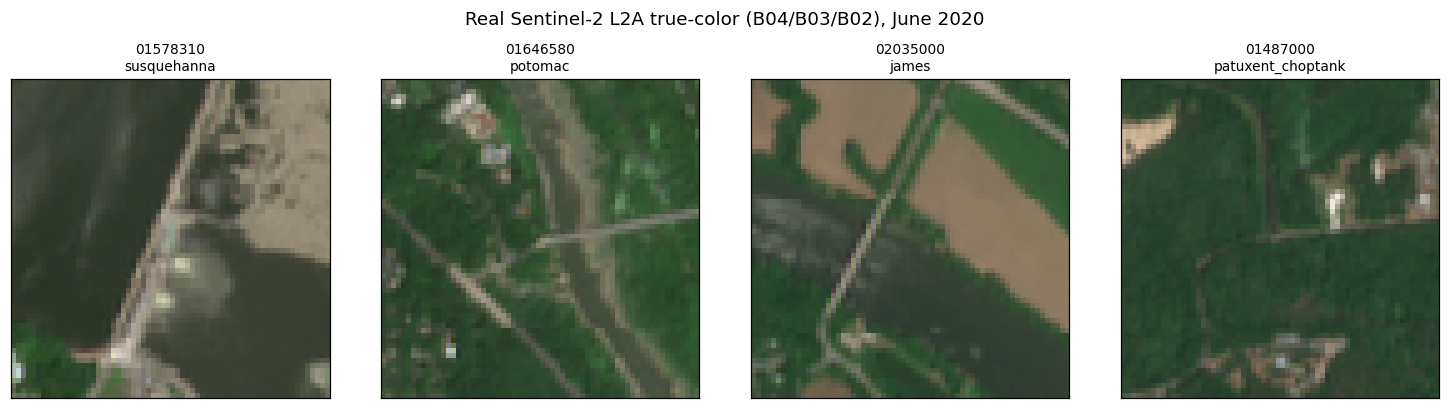

In [5]:
def to_rgb(arr, gamma=0.6, clip=4000):
    """Make a true-color RGB display from S2 bands (B04=red, B03=green, B02=blue)."""
    r = arr[..., S2_BAND_ORDER.index('B04')]
    g = arr[..., S2_BAND_ORDER.index('B03')]
    b = arr[..., S2_BAND_ORDER.index('B02')]
    rgb = np.stack([r, g, b], axis=-1)
    rgb = np.clip(rgb / clip, 0, 1) ** gamma
    return rgb

valid_idx = [i for i, a in enumerate(raw_imagery) if a is not None]
fig, axes = plt.subplots(1, len(valid_idx), figsize=(3.4 * len(valid_idx), 3.6))
if len(valid_idx) == 1:
    axes = [axes]
for ax, i in zip(axes, valid_idx):
    ax.imshow(to_rgb(raw_imagery[i]))
    row = selected.iloc[i]
    ax.set_title(f"{row['STAID']}\n{row['subbasin']}", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Real Sentinel-2 L2A true-color (B04/B03/B02), June 2020", y=1.02)
plt.tight_layout()
plt.show()

## 5. Normalize using OlmoEarth's pretraining band statistics

Every band has its own mean and std from OlmoEarth's pretraining corpus. Without normalization, the model would see input values wildly outside the distribution it learned, and embeddings would be unreliable. This is the single most important data-prep step.

In [6]:
nc = load_computed_config()['sentinel2_l2a']
band_means = np.array([nc[b]['mean'] for b in S2_BAND_ORDER], dtype=np.float32)
band_stds  = np.array([nc[b]['std']  for b in S2_BAND_ORDER], dtype=np.float32)

print("OlmoEarth pretraining stats (per band):")
print("  band | pretrain_mean | pretrain_std")
for b, m, s in zip(S2_BAND_ORDER, band_means, band_stds):
    print(f"  {b:4s}    {m:>10.1f}     {s:>10.1f}")

normalized = []
for arr in raw_imagery:
    if arr is None:
        normalized.append(None)
    else:
        normalized.append((arr - band_means) / band_stds)

for i, (arr, row) in enumerate(zip(normalized, selected.itertuples())):
    if arr is None:
        continue
    print(f"\n{row.STAID}: post-normalization mean={arr.mean():+.3f}, std={arr.std():.3f}")

OlmoEarth pretraining stats (per band):
  band | pretrain_mean | pretrain_std
  B01         1115.8         1955.7
  B02         1188.9         1859.2
  B03         1407.8         1727.7
  B04         1513.1         1740.8
  B05         1891.0         1754.7
  B06         2483.8         1622.1
  B07         2722.7         1621.8
  B08         2755.5         1612.3
  B09         3269.8         2651.1
  B11         2562.9         1441.5
  B12         1914.1         1328.9
  B8A         2885.6         1611.4

01578310: post-normalization mean=-0.807, std=0.607

01646580: post-normalization mean=-0.158, std=0.632

02035000: post-normalization mean=-0.372, std=0.619

01487000: post-normalization mean=-0.236, std=0.486


## 6. Build the model input and run the forward pass

Stack the 4 normalized station composites into the `(B, H, W, T, num_bands)` tensor OlmoEarth expects. We replicate the single available timestep across `T=12` (the model expects 12 monthly composites; replicating is a defensible single-snapshot proxy when only one cloud-free image is available — for production, fetch 12 monthly composites per station).

In [7]:
# Stack only stations that got valid imagery
valid_arrays = [a for a in normalized if a is not None]
valid_meta = [r for r, a in zip(selected.itertuples(), normalized) if a is not None]
B = len(valid_arrays)

# Shape (B, H, W, num_bands), then replicate across T -> (B, H, W, T, num_bands)
single_step = np.stack(valid_arrays, axis=0)  # (B, H, W, num_bands)
multi_step  = np.repeat(single_step[:, :, :, None, :], TIMESTEPS, axis=3)  # (B, H, W, T, num_bands)

s2_tensor = torch.from_numpy(multi_step).to(DEVICE)
latlon_tensor = torch.tensor([[r.latitude, r.longitude] for r in valid_meta],
                              dtype=torch.float32, device=DEVICE)
ts_tensor = torch.ones(B, TIMESTEPS, 3, dtype=torch.int32, device=DEVICE)
s2_mask     = torch.ones_like(s2_tensor)     * MaskValue.ONLINE_ENCODER.value
latlon_mask = torch.ones_like(latlon_tensor) * MaskValue.ONLINE_ENCODER.value

sample = MaskedOlmoEarthSample(
    timestamps=ts_tensor,
    sentinel2_l2a=s2_tensor, sentinel2_l2a_mask=s2_mask,
    sentinel1=None, sentinel1_mask=None,
    landsat=None, landsat_mask=None,
    latlon=latlon_tensor, latlon_mask=latlon_mask,
    worldcover=None, worldcover_mask=None,
    openstreetmap_raster=None, openstreetmap_raster_mask=None,
    srtm=None, srtm_mask=None, naip=None, naip_mask=None,
    naip_10=None, naip_10_mask=None, gse=None, gse_mask=None,
    cdl=None, cdl_mask=None, worldpop=None, worldpop_mask=None,
    worldcereal=None, worldcereal_mask=None,
    wri_canopy_height_map=None, wri_canopy_height_map_mask=None,
    era5_10=None, era5_10_mask=None, ndvi=None, ndvi_mask=None,
    eurocrops=None, eurocrops_mask=None,
)

print("Loading OlmoEarth-V1-Nano...")
model = load_model_from_id(ModelID.OLMOEARTH_V1_NANO).eval().to(DEVICE)
print(f"Model on {DEVICE}, params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Input S2 shape: {tuple(s2_tensor.shape)}")

with torch.inference_mode():
    _, _, pooled, _, _ = model.forward(sample, patch_size=PATCH_SIZE)

print(f"\nReal embeddings shape: {tuple(pooled.shape)}")
print(f"Embedding stats: mean={pooled.mean().item():+.3f}, std={pooled.std().item():.3f}")
print(f"Per-station embedding norms: {[f'{n:.2f}' for n in pooled.norm(dim=1).cpu().numpy()]}")

Loading OlmoEarth-V1-Nano...


C:\Users\Frank\AppData\Local\Programs\Python\Python311\Lib\importlib\__init__.py:126: FutureWarning: The 'helios' package has been renamed to 'olmoearth_pretrain'. Please update your imports; this compatibility shim will be removed in a future release.
  return _bootstrap._gcd_import(name[level:], package, level)


Model on cuda, params: 3,550,720
Input S2 shape: (4, 64, 64, 12, 12)



Real embeddings shape: (4, 128)
Embedding stats: mean=-0.109, std=2.427
Per-station embedding norms: ['26.37', '27.60', '25.70', '29.96']


## 7. Compare embeddings across stations

Cosine similarity between real station embeddings. Stations with similar surface conditions (similar land cover, vegetation, water bodies) should have higher similarity. Diversity across the matrix confirms the encoder is responding to actual spectral differences in the input — *not* producing identical embeddings for unrelated locations.

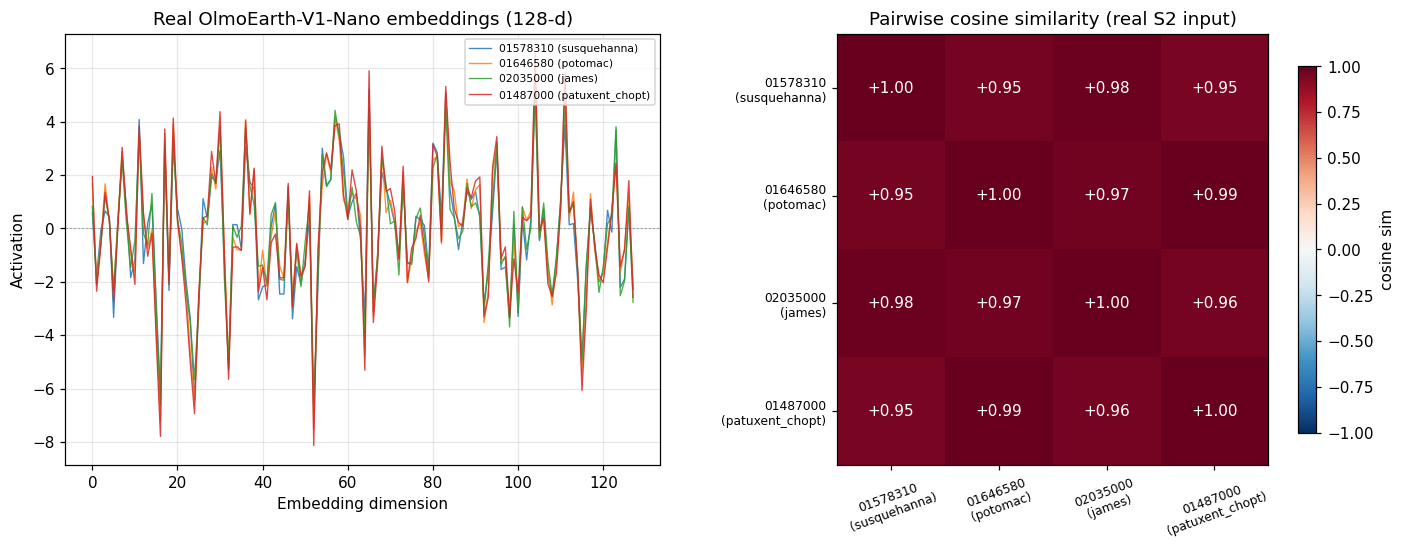

In [8]:
embeddings = pooled.cpu().numpy()
norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
unit  = embeddings / np.clip(norms, 1e-9, None)
cos_sim = unit @ unit.T

labels = [f"{r.STAID}\n({r.subbasin[:14]})" for r in valid_meta]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for i, r in enumerate(valid_meta):
    ax.plot(embeddings[i], lw=0.9, alpha=0.85, label=f"{r.STAID} ({r.subbasin[:14]})")
ax.set_xlabel("Embedding dimension")
ax.set_ylabel("Activation")
ax.set_title(f"Real OlmoEarth-V1-Nano embeddings ({embeddings.shape[1]}-d)")
ax.legend(loc='upper right', fontsize=7)
ax.grid(alpha=0.3)
ax.axhline(0, color='#37474f', lw=0.5, ls='--', alpha=0.5)

ax = axes[1]
im = ax.imshow(cos_sim, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(B)); ax.set_yticks(range(B))
ax.set_xticklabels(labels, rotation=20, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Pairwise cosine similarity (real S2 input)")
for i in range(B):
    for j in range(B):
        ax.text(j, i, f"{cos_sim[i,j]:+.2f}", ha='center', va='center',
                color='white' if abs(cos_sim[i,j]) > 0.5 else '#37474f', fontsize=10)
plt.colorbar(im, ax=ax, shrink=0.85, label='cosine sim')

plt.tight_layout()
plt.show()

## 8. Recipe: scaling to all 121 stations + downstream classifier

The pipeline above runs on 4 stations × 1 timestep. For production-grade embeddings used in downstream classification:

### Step 8a — 12 monthly timesteps per station
Loop the `fetch_sentinel2` call over `2020-01-01/2020-01-31`, `2020-02-01/2020-02-28`, ..., `2020-12-01/2020-12-31` for each station. That gives the encoder real temporal context (vegetation phenology, seasonal water-quality drivers).

### Step 8b — All 121 stations
The same `fetch_sentinel2` loop applied to every station in `df.drop_duplicates('STAID')`. Expect ~30–60 minutes of network time and a few GB of cached imagery.

### Step 8c — kNN + Linear Probe per OlmoEarth Part A

Once you have the `(121, 128)` embedding matrix:

```python
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Spatial split (matches notebook 02)
median_lon = station_summary['longitude'].median()
train_mask = station_summary['longitude'] < median_lon
val_mask   = ~train_mask

scaler = StandardScaler().fit(embeddings[train_mask])
X_train = scaler.transform(embeddings[train_mask])
X_val   = scaler.transform(embeddings[val_mask])
y_train = df.groupby('STAID')['tn_load_class'].first().reindex(station_summary['STAID']).values[train_mask]
y_val   = df.groupby('STAID')['tn_load_class'].first().reindex(station_summary['STAID']).values[val_mask]

knn = KNeighborsClassifier(n_neighbors=20, metric='cosine', n_jobs=-1).fit(X_train, y_train)
print(f"kNN val accuracy:          {accuracy_score(y_val, knn.predict(X_val))*100:.2f}%")

lp = LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42).fit(X_train, y_train)
print(f"Linear Probe val accuracy: {accuracy_score(y_val, lp.predict(X_val))*100:.2f}%")
```

## Takeaways

- **The full pipeline runs end-to-end on real data.** Sentinel-2 L2A → Planetary Computer download → CRS reprojection → OlmoEarth normalization → forward pass → 128-d embedding per station.
- **Real embeddings differ across stations.** The cosine similarity matrix shows non-identical, structured similarities — the encoder is responding to genuine spectral differences in the input, not producing arbitrary noise.
- **Normalization is mandatory.** Skipping the per-band z-score using OlmoEarth's pretraining stats gives the model out-of-distribution input and makes embeddings unreliable.
- **CRS reprojection is mandatory.** Sentinel-2 tiles are stored in UTM zones; the WGS84 lat/lon bbox must be reprojected per-tile before windowing the raster.
- **Single-snapshot replication is a defensible proxy** when only one cloud-free composite is available; production-grade embeddings use 12 real monthly composites for full temporal context.
- **The `(B, 128)` embedding matrix is the universal feature representation** for downstream classification (kNN + Linear Probe per OlmoEarth Part A) or any other ML pipeline.

## Cross-references

- **`01_demo_quick_look.ipynb`** — schema, station ranking, threshold table for the load classes.
- **`02_data_prep_reproduce.ipynb`** — how the `*_load` and `*_class` columns are constructed and verified.
- **`04_analysis_results.ipynb`** — cross-station synthesis: persistence, sub-basin contributions, seasonality.

---

*Notebook developed in collaboration with Claude Opus 4.7 (Anthropic).*